# Iris Flower Classification

## Objective

The objective of this project is to classify Iris flowers into Setosa, Versicolor, and Virginica using Machine Learning algorithms.

Algorithms Used:
- Logistic Regression
- Decision Tree

Dataset:
- Iris Dataset (Scikit-Learn)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report



## Load The Dataset

In [3]:
iris=load_iris()
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Exploratary Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [7]:
df['target']=iris.target

In [8]:
df['species']=df['target'].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

In [9]:
df['species'].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

In [10]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [11]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Visualization

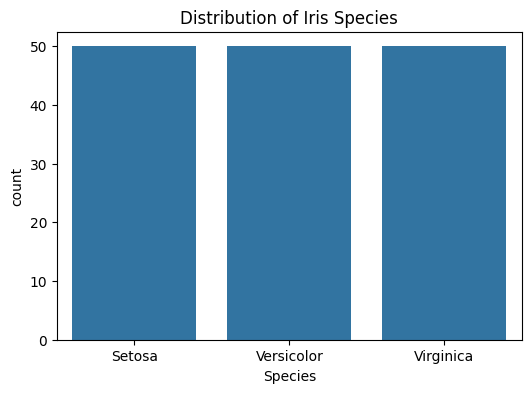

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='species', data=df)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("count")

plt.show()

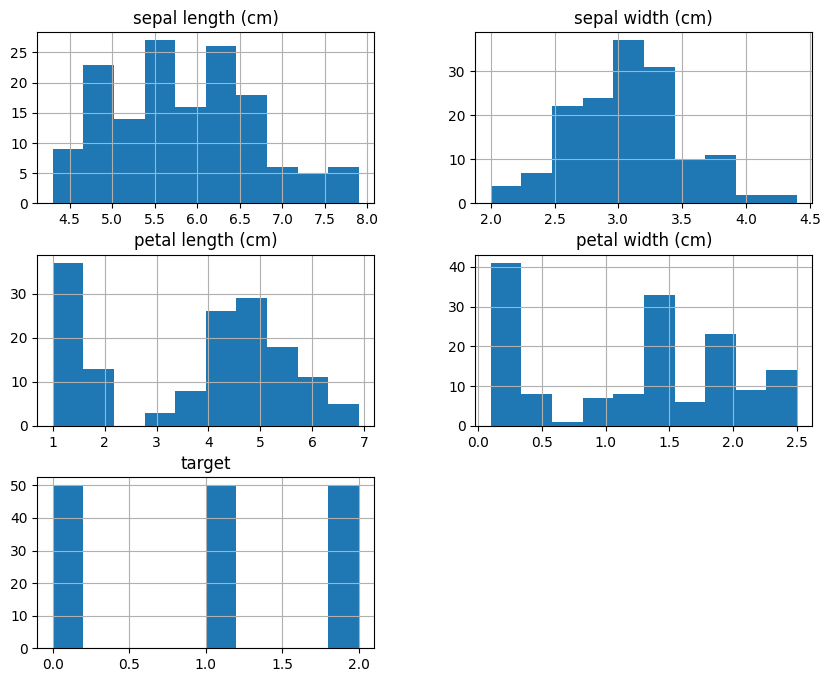

In [13]:
df.hist(figsize=(10,8))
plt.show()

- All three Iris species contain 50 samples each.
The dataset is balanced.
A balanced dataset reduces the chance of the model favoring one class over another and generally helps produce more reliable classification results.

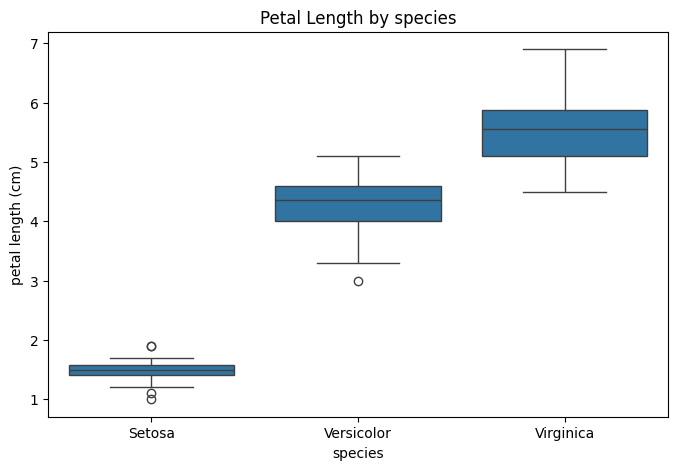

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='species',y='petal length (cm)',data=df)

plt.title("Petal Length by species")

plt.show()


- Sentosa has the smallest petal length 
Virginica has the largest petal length 

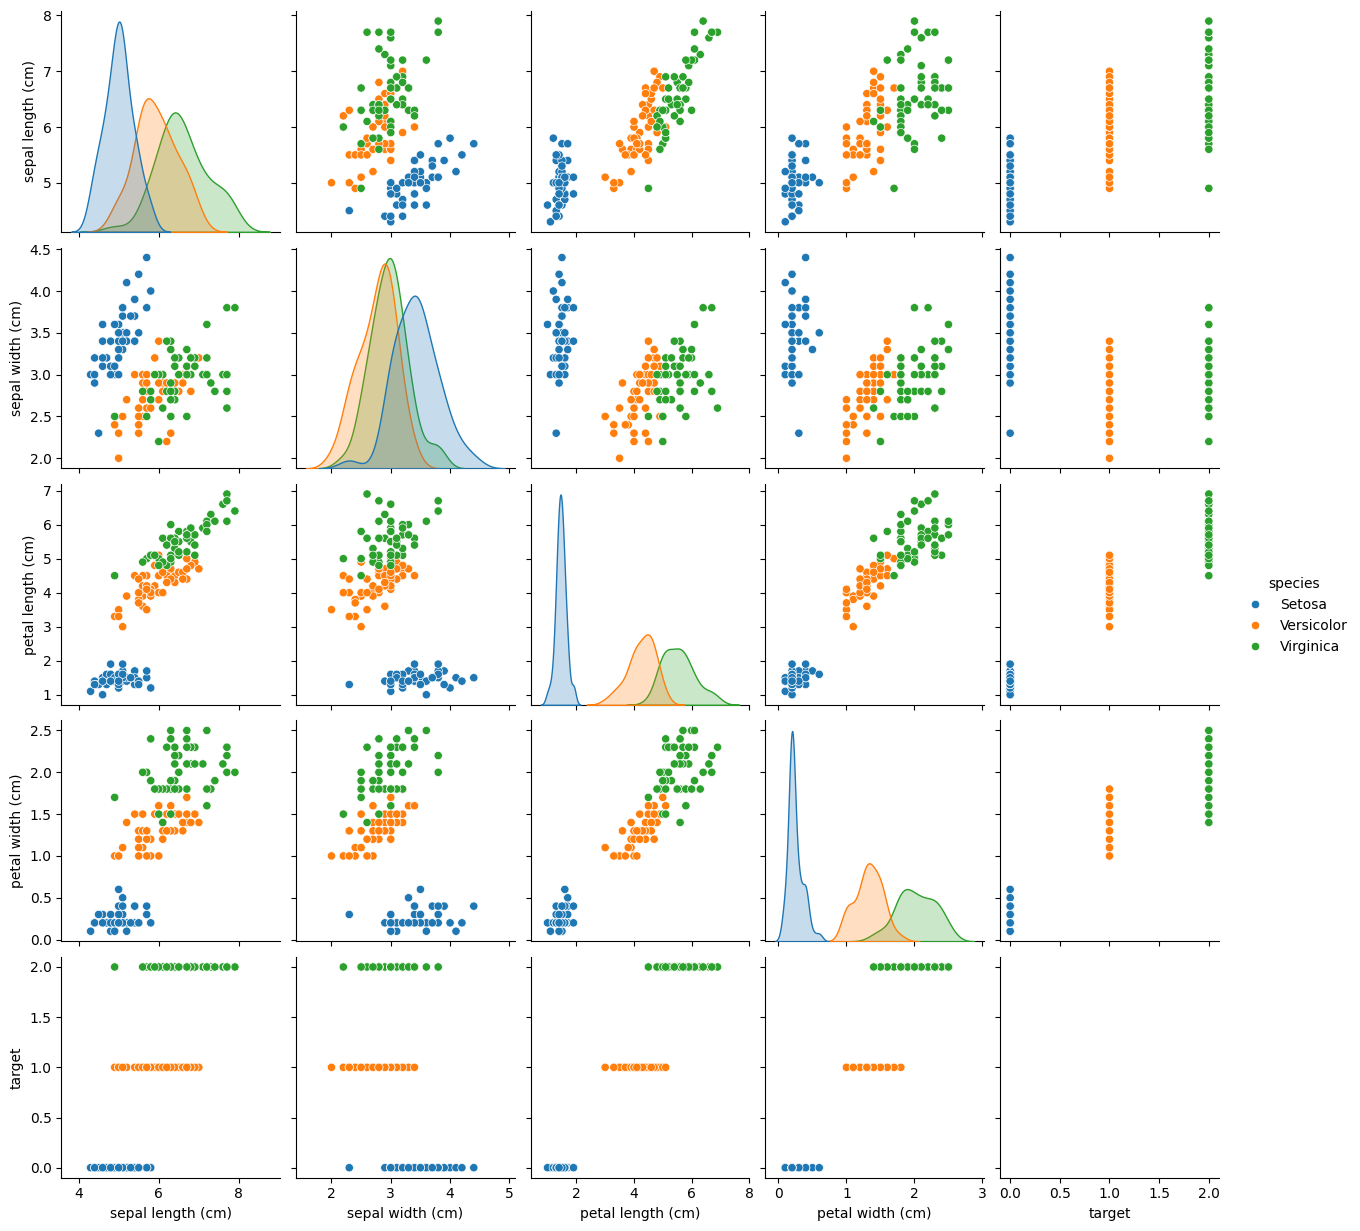

In [15]:
sns.pairplot(df, hue='species')
plt.show()

#### Observation
- Setosa is clearly separated from the other two species in most feature combinations.
- Versicolor and Virginica show slight overlap, indicating they are more similar.
- Petal Length and Petal Width provide better class separation than Sepal Width.
- The clear clustering suggests that the dataset is suitable for classification algorithms.

<Axes: >

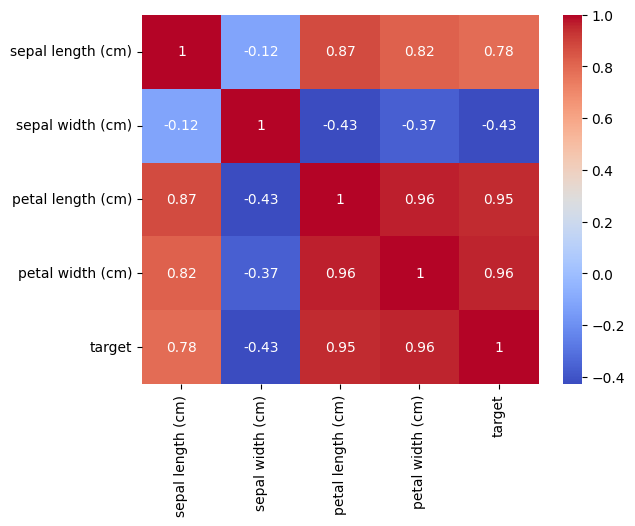

In [16]:
sns.heatmap(df.drop(columns=['species']).corr(),annot=True, cmap='coolwarm')

## Train/Test split 

In [17]:

X=df[iris.feature_names]
y=df['species']

X_train, X_test, y_train ,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print("Training Samples", X_train.shape[0])
print("Testing Samples", X_test.shape[0])

Training Samples 120
Testing Samples 30


## Model Evaluation

In [18]:
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [19]:
y_pred=model.predict(X_test)

In [20]:
compasrion = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

compasrion.head()

,Actual,Predicted
38,Setosa,Setosa
127,Virginica,Virginica
57,Versicolor,Versicolor
93,Versicolor,Versicolor
42,Setosa,Setosa


In [21]:

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\nClassification Report:", classification_report(y_test,y_pred))

Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Observation
The model correctly classified most flowers. However, a few Versicolor flowers were predicted as Virginica. This is expected because these two species have similar characteristics and overlap slightly in the feature space, as observed during the Exploratory Data Analysis (EDA).

**Accuracy**
- Logistic Regression achieved an accuracy of 96.67% on the test dataset.

**Confusion Matrix**

- All Setosa and Virginica flowers were classified correctly.
One Versicolor flower was incorrectly classified as Virginica.

**Classification Report**
- Setosa achieved perfect precision, recall, and F1-score (1.00).
Versicolor had a slightly lower recall due to one misclassification.
Virginica had a slightly lower precision because one Versicolor flower was predicted as Virginica.

*Conclusion*

- Logistic Regression performed exceptionally well on the Iris dataset, achieving 96.67% accuracy. The only error occurred between Versicolor and Virginica, which is expected because these two species have similar feature characteristics, as observed during the EDA.

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train,y_train)

dt_pred= dt_model.predict(X_test)

In [23]:
print("Accuracy ",accuracy_score(y_test,dt_pred))
print("Confussion matric ",confusion_matrix(y_test,dt_pred))
print("Classification report  ",classification_report(y_test,dt_pred))

Accuracy  0.9333333333333333
Confussion matric  [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
Classification report                 precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [25]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.966667
1,Decision Tree,0.933333


#### Final Outcome

**Best Performing Model**: Logistic Regression

**Final Accuracy**: 96.67%

- This model was selected as the final classifier because it achieved the highest accuracy and demonstrated excellent performance in classifying the three Iris flower species.

#### Conclusion
- In this project, the Iris Flower Classification problem was solved using Machine Learning techniques. The dataset was first explored through Exploratory Data Analysis (EDA) to understand the distribution of features, relationships between variables, and class balance. Visualizations such as count plots, histograms, box plots, pair plots, and correlation heatmaps provided valuable insights into the characteristics of the three Iris species.

- Two classification algorithms, Logistic Regression and Decision Tree Classifier, were trained and evaluated using the Iris dataset. The performance of both models was assessed using Accuracy Score, Confusion Matrix, and Classification Report.

**The results showed that**:

- Logistic Regression achieved an accuracy of 96.67%.
- Decision Tree Classifier achieved an accuracy of 93.33%.

- Although both models performed well, Logistic Regression provided higher accuracy and fewer misclassifications, making it the better-performing model for this dataset.

- Overall, this project demonstrated the complete Machine Learning workflow, including data exploration, preprocessing, model training, prediction, evaluation, and comparison of multiple classification algorithms. It also highlighted the importance of selecting the most suitable model based on performance rather than assuming one algorithm is always better than another.